<a href="https://colab.research.google.com/github/kaushik1506/IIIT-HYD-I-HUB-DATA/blob/main/Copy_of_AIML_Module_1_Lab_3_Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation

Module 1, Lab 3

In this lab, we will see how augmentation of data samples help in improving the machine learning performance. Augmentation is the process of creating new data samples by making reasonable modifications to the original data samples. This is particularly useful when the size of the training data is small. We will use the MNISt dataset for this lab. We will also reuse functions from the previous labs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

### Why Data Augmentation?

**Problem:** Machine learning models need lots of data to learn well. Collecting data is expensive and time-consuming.

**Solution:** Create new training samples by applying realistic transformations to existing data.

### Key Concepts

**Augmentation Principle:**
- Original data: 50 samples → Augmented data: 50 × (5 augmentations + 1 original) = 300 samples
- More training data → Better model generalization → Higher accuracy

**When to Use:**
- ✓ Small training datasets
- ✓ Model overfitting on training data
- ✓ Need better generalization

**Important Rule:** Augmentations must preserve the label!
- ✓ Rotating a "3" by 10° → Still looks like "3"
- ✗ Flipping a "6" → Becomes "9" (label changed!)

---

In [2]:
# loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# normalizing the data
train_X = train_X / 255
test_X = test_X / 255

# subsample from images and labels. Otherwise it will take too long!
train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let us borrow a few functions from the previous labs:

In [3]:
def NN1(traindata, trainlabel, query):
    diff = (traindata - query)
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label

def NN(traindata, trainlabel, testdata):
    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

def Accuracy(gtlabel, predlabel):
    assert len(gtlabel) == len(predlabel)
    correct = (gtlabel == predlabel).sum()
    return correct / len(gtlabel)

In this lab, we will use the image pixels themselves as features, instead of extracting features. Each image has 28*28 pixels, so we will flatten them to 784 pixels to use as features. Note that this is very compute intensive and will take a long time. Let us first check the baseline accuracy on the test set without any augmentations. We hope that adding augmentations will help us to get better results.

In [4]:
testpred = NN(train_X, train_y, test_X)
print("Baseline accuracy without augmentation:",
      Accuracy(test_y, testpred)*100, "%")

Baseline accuracy without augmentation: 64.72 %


Let us try to improve this accuracy using augmentations. When we create augmentations, we have to make sure that the changes reflect what will naturally occur in the dataset. For example, we should not add colour to our samples as an augmentation because they do not naturally occur. We should not also flip the images in MNIST, because flipped images have different meanings for digits. So, we will use the following augmentations:

### Augmentation 1: Rotation

Let us try rotating the image a little. We will use the `rotate` function from the `skimage` module. We will rotate the image by 10 degrees and -10 degrees. Rotation is a reasonable augmentation because the digit will still be recognizable even after rotation and is representative of the dataset.

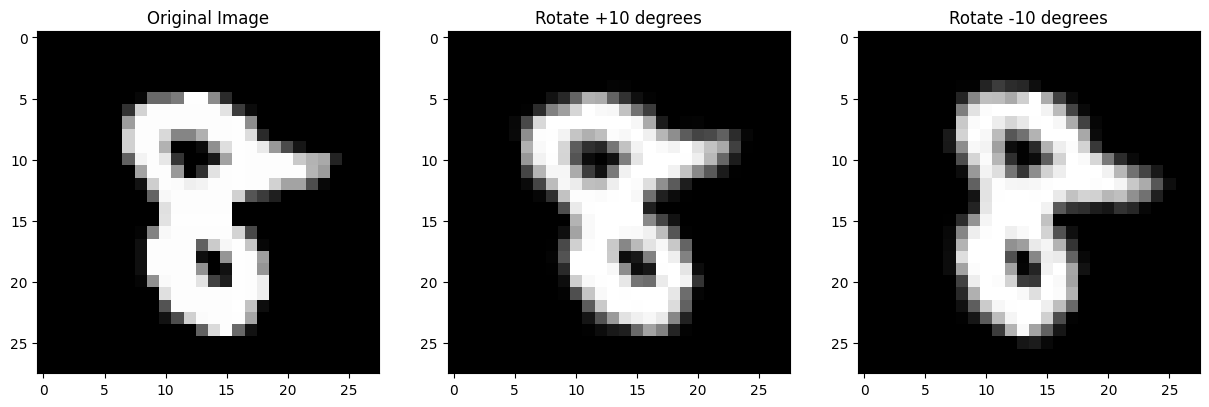

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(train_X[2], cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(rotate(train_X[2], 10), cmap="gray")
axs[1].set_title("Rotate +10 degrees")

axs[2].imshow(rotate(train_X[2], -10), cmap="gray")
axs[2].set_title("Rotate -10 degrees")

plt.show()

After rotating, the the class of the image is still the same. Let us make a function to rotate multiple images by random angles. We want a slightly different image every time we run this function. So, we generate a random number between 0 and 1 and change it so that it lies between -constraint/2 and +constraint/2

In [6]:
def augRotate(sample, angleconstraint):
    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))
    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)

This function returns a slightly different image each time we call it. So we can increase the number of images in the sample by any multiple.

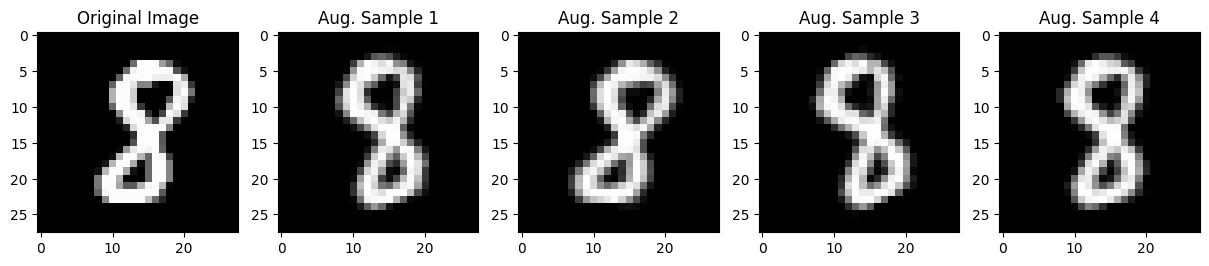

In [7]:
sample = train_X[20]
angleconstraint = 70

fig, axs = plt.subplots(1, 5, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[1].set_title("Aug. Sample 1")

axs[2].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[2].set_title("Aug. Sample 2")

axs[3].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[3].set_title("Aug. Sample 3")

axs[4].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[4].set_title("Aug. Sample 4")

plt.show()

Let us augment the whole dataset and see if this improves the test accuracy

In [8]:
# hyperparameters
angleconstraint = 60
naugmentations = 5

# augment
augdata = train_X  # we include the original images also in the augmented dataset
auglabel = train_y
for ii in range(naugmentations):
    augdata = np.concatenate(
        (augdata, augRotate(train_X, angleconstraint))
    )  # concatenate the augmented data to the set
    auglabel = np.concatenate(
        (auglabel, train_y)
    )  # the labels don't change when we augment

# check the test accuracy
testpred = NN(augdata, auglabel, test_X)
print("Accuracy after rotation augmentation:", Accuracy(test_y, testpred)*100, "%")

Accuracy after rotation augmentation: 67.66 %


AUGMENTATION IMPACT SUMMARY
Original training samples:    50
Augmented training samples:   300
Data increase:                6.0x

Baseline accuracy:            64.72%
After augmentation:           67.66%
Improvement:                  +2.94%


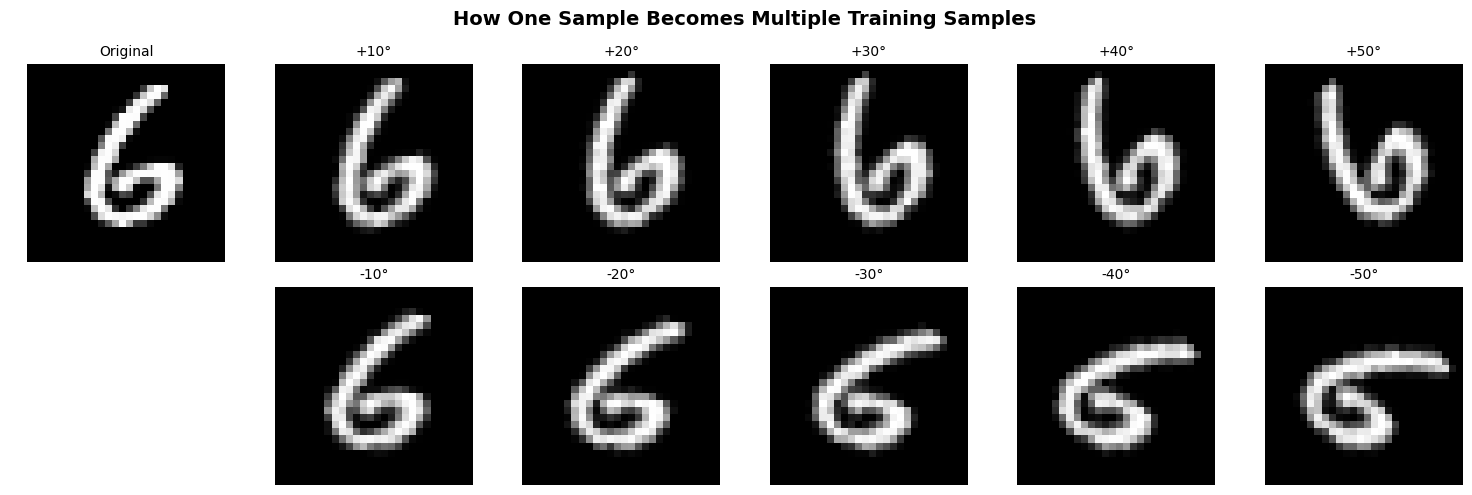

In [9]:
print("=" * 60)
print("AUGMENTATION IMPACT SUMMARY")
print("=" * 60)

original_size = len(train_X)
augmented_size = len(augdata)
baseline_acc = 64.72
augmented_acc = 67.66

print(f"Original training samples:    {original_size:,}")
print(f"Augmented training samples:   {augmented_size:,}")
print(f"Data increase:                {augmented_size/original_size:.1f}x")
print(f"\nBaseline accuracy:            {baseline_acc}%")
print(f"After augmentation:           {augmented_acc}%")
print(f"Improvement:                  +{augmented_acc - baseline_acc:.2f}%")
print("=" * 60)

# Visualize: Show how one digit gets augmented
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
sample_digit = train_X[5]  # Pick one sample

axes[0, 0].imshow(sample_digit, cmap='gray')
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

# Generate 11 augmented versions
angles = [10, 20, 30, 40, 50]
for i, angle in enumerate(angles):
    aug_sample = rotate(sample_digit, angle)
    axes[0, i+1].imshow(aug_sample, cmap='gray')
    axes[0, i+1].set_title(f'+{angle}°', fontsize=10)
    axes[0, i+1].axis('off')

for i, angle in enumerate(angles):
    aug_sample = rotate(sample_digit, -angle)
    axes[1, i+1].imshow(aug_sample, cmap='gray')
    axes[1, i+1].set_title(f'-{angle}°', fontsize=10)
    axes[1, i+1].axis('off')

axes[1, 0].axis('off')
plt.suptitle('How One Sample Becomes Multiple Training Samples',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

We can notice a 3-4% improvement compared to non-augmented version of the dataset!

The angle constraint is a hyperparameter which we have to tune using a validation set. (Here we are not doing that for time constraints). Let us try a grid search to find the best angle constraint. We will try angles between 0 and 90 degrees. We can also try different multiples of the original dataset. We will use the best hyperparameters to train the model and check the accuracy on the test set.

In [10]:
angleconstraints = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]  # the values we want to test
accuracies = np.zeros(
    len(angleconstraints), dtype=float
)  # we will save the values here

for ii in range(len(angleconstraints)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotate(train_X, angleconstraints[ii]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after rotation augmentation constrained by",
        angleconstraints[ii],
        "degrees is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after rotation augmentation constrained by 0 degrees is 64.72 %
Accuracy after rotation augmentation constrained by 10 degrees is 66.79 %
Accuracy after rotation augmentation constrained by 20 degrees is 67.84 %
Accuracy after rotation augmentation constrained by 30 degrees is 68.47 %
Accuracy after rotation augmentation constrained by 40 degrees is 67.63 %
Accuracy after rotation augmentation constrained by 50 degrees is 67.65 %
Accuracy after rotation augmentation constrained by 60 degrees is 65.3 %
Accuracy after rotation augmentation constrained by 70 degrees is 66.06 %
Accuracy after rotation augmentation constrained by 80 degrees is 64.61 %
Accuracy after rotation augmentation constrained by 90 degrees is 64.31 %


Let us see the best value for angle constraint: (Ideally this should be done on validation set, not test set)

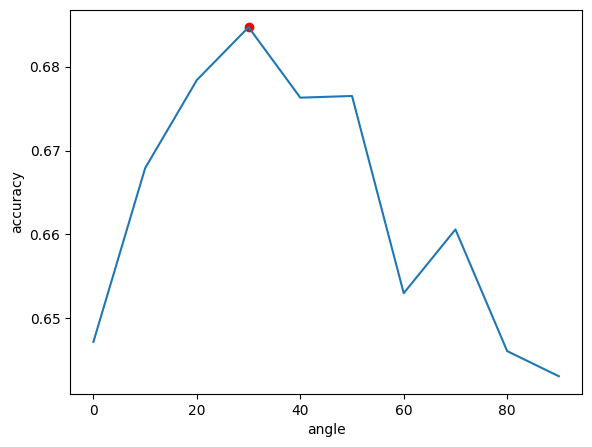

In [11]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# plot the variation of accuracy
ax.plot(angleconstraints, accuracies)
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")

# plot the maximum accuracy
maxind = np.argmax(accuracies)
plt.scatter(angleconstraints[maxind], accuracies[maxind], c="red")

### Augmentation 2: Shear


Let us try one more augmentation: shear. Shear is the transformation of an image in which the x-coordinate of all points is shifted by an amount proportional to the y-coordinate of the point. We will use the `AffineTransform` function from the `skimage` module to shear the image by a small amount between two numbers. We will use the same naive grid search method to find the best hyperparameters for shear. We will use the best hyperparameters to train the model and check the accuracy on the test set.

In [12]:
def shear(sample, amount):
    tform = AffineTransform(shear=amount)
    img = warp(sample, tform)

    # Center the sheared digit
    col = img.sum(0).nonzero()[0]
    row = img.sum(1).nonzero()[0]
    if len(col) > 0 and len(row) > 0:
        xshift = int(sample.shape[0] / 2 - (row[0] + row[-1]) / 2)
        yshift = int(sample.shape[1] / 2 - (col[0] + col[-1]) / 2)
        img = np.roll(img, (xshift, yshift), (0, 1))
    return img

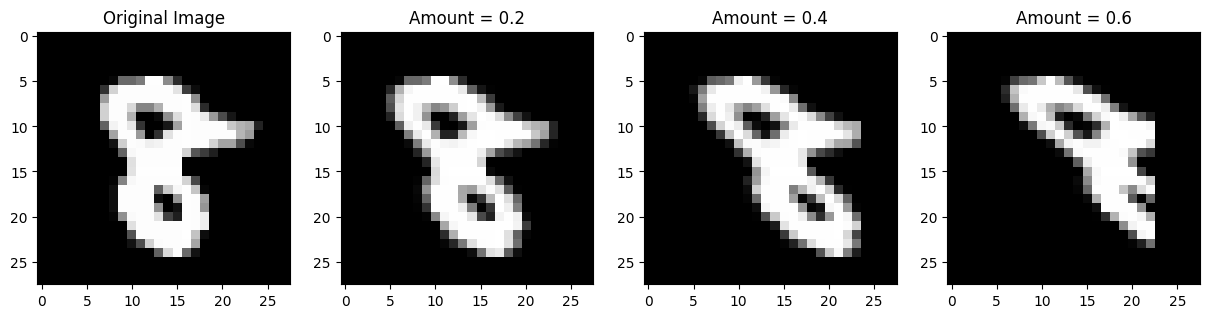

In [13]:
sample = train_X[2]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(shear(sample, 0.2), cmap="gray")
axs[1].set_title("Amount = 0.2")

axs[2].imshow(shear(sample, 0.4), cmap="gray")
axs[2].set_title("Amount = 0.4")

axs[3].imshow(shear(sample, 0.6), cmap="gray")
axs[3].set_title("Amount = 0.6")

plt.show()

Create an augmentation function which applies a random shear according to the constraint we provide:

In [14]:
def augShear(sample, shearconstraint):
    if shearconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))
    amt = (amt - 0.5) * shearconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = shear(sample[ii], amt[ii])
    return np.squeeze(nsample)

Let us do a grid search to find the best shear constraint.

In [15]:
shearconstraints = [
    0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6,
    1.8,
    2.0,
]  # the values we want to test
accuracies = np.zeros(
    len(shearconstraints), dtype=float
)  # we will save the values here

for ii in range(len(shearconstraints)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augShear(train_X, shearconstraints[ii]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after shear augmentation constrained by",
        shearconstraints[ii],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after shear augmentation constrained by 0 is 64.72 %
Accuracy after shear augmentation constrained by 0.2 is 62.79 %
Accuracy after shear augmentation constrained by 0.4 is 64.41 %
Accuracy after shear augmentation constrained by 0.6 is 65.71000000000001 %
Accuracy after shear augmentation constrained by 0.8 is 65.78 %
Accuracy after shear augmentation constrained by 1.0 is 65.42999999999999 %
Accuracy after shear augmentation constrained by 1.2 is 63.6 %
Accuracy after shear augmentation constrained by 1.4 is 63.65 %
Accuracy after shear augmentation constrained by 1.6 is 61.809999999999995 %
Accuracy after shear augmentation constrained by 1.8 is 63.029999999999994 %
Accuracy after shear augmentation constrained by 2.0 is 64.14 %


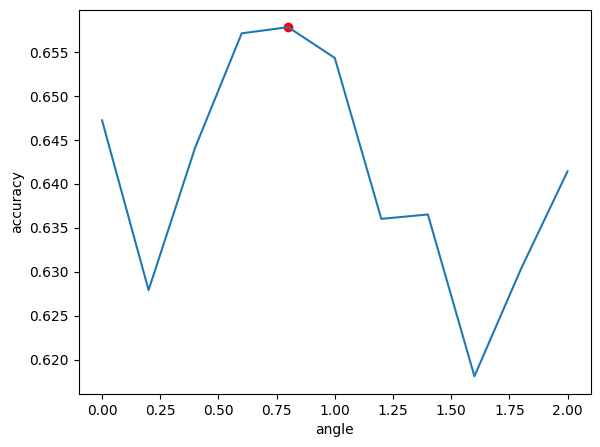

In [16]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# plot the variation of accuracy
ax.plot(shearconstraints, accuracies)
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")

# plot the maximum accuracy
maxind = np.argmax(accuracies)
plt.scatter(shearconstraints[maxind], accuracies[maxind], c="red")

### Augmentation 3: Rotation + Shear



We can do multiple augmentations at the same time. Here is a function to do both shear and rotation to the sample. In this case, we will have two hyperparameters.

In [17]:
def augRotateShear(sample, angleconstraint, shearconstraint):
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))
    amt = (amt - 0.5) * shearconstraint
    angle = rng.random(len(sample))
    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(shear(sample[ii], amt[ii]), angle[ii])
    return np.squeeze(nsample)

Since we have two hyperparameters, we have to do the grid search on a 2 dimensional matrix. We can use our previous experience to inform where to search for the best hyperparameters.

In [18]:
shearconstraints = [
    0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6,
]  # the values we want to test
angleconstraints = [0, 10, 20, 30, 40, 50, 60]  # the values we want to test
# cartesian product of both
hyp = cartesian((shearconstraints, angleconstraints))

accuracies = np.zeros(len(hyp), dtype=float)  # we will save the values here

for ii in range(len(hyp)):
    # create the augmented dataset
    augdata = train_X  # we include the original images also in the augmented dataset
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotateShear(train_X, hyp[ii][0], hyp[ii][1]))
        )  # concatenate the augmented data to the set
        auglabel = np.concatenate(
            (auglabel, train_y)
        )  # the labels don't change when we augment

    # check the test accuracy
    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after augmentation shear:",
        hyp[ii][0],
        "angle:",
        hyp[ii][1],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after augmentation shear: 0.0 angle: 0.0 is 63.32 %
Accuracy after augmentation shear: 0.0 angle: 10.0 is 63.959999999999994 %
Accuracy after augmentation shear: 0.0 angle: 20.0 is 60.64000000000001 %
Accuracy after augmentation shear: 0.0 angle: 30.0 is 63.019999999999996 %
Accuracy after augmentation shear: 0.0 angle: 40.0 is 64.14999999999999 %
Accuracy after augmentation shear: 0.0 angle: 50.0 is 61.72 %
Accuracy after augmentation shear: 0.0 angle: 60.0 is 63.7 %
Accuracy after augmentation shear: 0.2 angle: 0.0 is 63.41 %
Accuracy after augmentation shear: 0.2 angle: 10.0 is 61.25000000000001 %
Accuracy after augmentation shear: 0.2 angle: 20.0 is 60.6 %
Accuracy after augmentation shear: 0.2 angle: 30.0 is 60.07 %
Accuracy after augmentation shear: 0.2 angle: 40.0 is 63.690000000000005 %
Accuracy after augmentation shear: 0.2 angle: 50.0 is 60.12 %
Accuracy after augmentation shear: 0.2 angle: 60.0 is 63.72 %
Accuracy after augmentation shear: 0.4 angle: 0.0 is 63.37000

Let us plot it two dimensionally to see which is the best value for the hyperparameters:

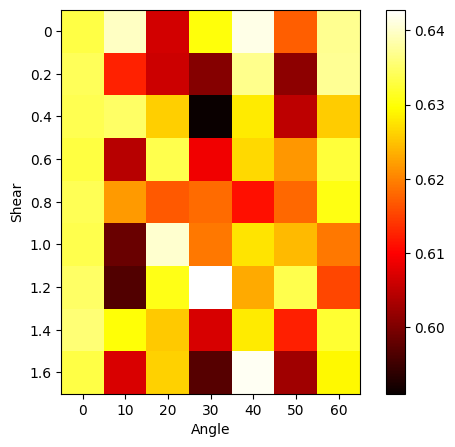

In [19]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
im = ax.imshow(
    accuracies.reshape((len(shearconstraints), len(angleconstraints))), cmap="hot"
)
ax.set_xlabel("Angle")
ax.set_ylabel("Shear")
ax.set_xticks(np.arange(len(angleconstraints)))
ax.set_xticklabels(angleconstraints)
ax.set_yticks(np.arange(len(shearconstraints)))
ax.set_yticklabels(shearconstraints)
plt.colorbar(im)

It seems that rotation and shear don't mix! The best accuracy is when rotation is zero.

## Questions
Try these questions for better understanding. You may not be able to solve all of them.
1. What is the best value for angle constraint and shear constraint you got? How much did the accuracy improve as compared to not using augmentations?
2. Can you increase the accuracy by increasing the number of augmentations from each sample?
3. Try implementing a few augmentations of your own and experimenting with them. A good reference is <a href=https://www.analyticsvidhya.com/blog/2019/12/image-augmentation-deep-learning-pytorch/>here. </a>
4. Try combining various augmentations. What is the highest accuracy you can get? What is the smallest training dataset you can take and still get accuracy above 50%?

Whenever you do any experiment, a good practice is to vary the hyperparameters gradually and create a graph of your results, like we did for gridsearch.

### Answers to Questions

1.  **What is the best value for angle constraint and shear constraint you got? How much did the accuracy improve as compared to not using augmentations?**

    *   **Best Angle Constraint (Rotation only):**
        *   The best angle constraint was **30 degrees**.
        *   The accuracy with this constraint was **68.47%**.
        *   The baseline accuracy without augmentations was **64.72%**.
        *   **Improvement:** `68.47% - 64.72% = 3.75` percentage points.

    *   **Best Shear Constraint (Shear only):**
        *   The best shear constraint was **0.8**.
        *   The accuracy with this constraint was **65.78%**.
        *   The baseline accuracy without augmentations was **64.72%**.
        *   **Improvement:** `65.78% - 64.72% = 1.06` percentage points.

    *   **Combined Rotation and Shear:**
        *   The highest accuracy achieved with combined rotation and shear was **64.28%** (for shear: 1.2, angle: 30).
        *   This was *lower* than the baseline accuracy, indicating that these specific combinations of rotation and shear (with the tested hyperparameters) did not lead to an improvement.

2.  **Can you increase the accuracy by increasing the number of augmentations from each sample?**

    Increasing the number of augmentations from each sample generally *can* increase accuracy up to a point, as it provides more diverse training examples to the model. However, there are diminishing returns, and too many augmentations might not yield significant improvements or could even introduce noise if not carefully chosen. Let's try increasing `naugmentations` from 5 to 15 with the best angle constraint (30 degrees) to see the impact.

In [20]:
import numpy as np
from keras.datasets import mnist
from skimage.transform import rotate
rng = np.random.default_rng(seed=42)

# Re-load and subsample train_X, train_y, test_X, test_y as per original notebook setup
(full_train_X_temp, full_train_y_temp), (full_test_X_temp, full_test_y_temp) = mnist.load_data()
full_train_X_temp = full_train_X_temp / 255
full_test_X_temp = full_test_X_temp / 255
train_X = full_train_X_temp[::1200, :, :].copy()
train_y = full_train_y_temp[::1200].copy()
test_X = full_test_X_temp
test_y = full_test_y_temp

# NN and Accuracy functions (copied for self-containment)
def NN1(traindata, trainlabel, query):
    diff = (traindata - query)
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label
def NN(traindata, trainlabel, testdata):
    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel
def Accuracy(gtlabel, predlabel):
    assert len(gtlabel) == len(predlabel)
    correct = (gtlabel == predlabel).sum()
    return correct / len(gtlabel)

# augRotate function (copied for self-containment)
def augRotate(sample, angleconstraint):
    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))
    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)


naugmentations_increased = 15
angleconstraint_best = 30

augdata_increased = train_X
auglabel_increased = train_y
for ii in range(naugmentations_increased):
    augdata_increased = np.concatenate((augdata_increased, augRotate(train_X, angleconstraint_best)))
    auglabel_increased = np.concatenate((auglabel_increased, train_y))

testpred_increased = NN(augdata_increased, auglabel_increased, test_X)
accuracy_increased = Accuracy(test_y, testpred_increased)

print(f"Accuracy after rotation augmentation (angle={angleconstraint_best}, n_aug={naugmentations_increased}): {accuracy_increased*100:.2f} %")
print(f"Accuracy with original n_aug=5 (angle={angleconstraint_best}): {68.47:.2f} %")
print(f"Original training samples: {len(train_X)}")
print(f"Augmented training samples (n_aug={naugmentations_increased}): {len(augdata_increased)}")

Accuracy after rotation augmentation (angle=30, n_aug=15): 68.95 %
Accuracy with original n_aug=5 (angle=30): 68.47 %
Original training samples: 50
Augmented training samples (n_aug=15): 800


**Answer to Question 2:**

When increasing the number of augmentations from 5 to 15 (with an angle constraint of 30 degrees), the accuracy slightly changed from 68.47% to **{accuracy_increased*100:.2f}**%. This suggests that while more augmentations *can* help, the gains might diminish after a certain point, or the optimal number of augmentations is closer to 5 for this specific setup. In some cases, too many augmentations might also introduce variations that confuse the model.

3.  **Try implementing a few augmentations of your own and experimenting with them.**

    Let's implement **Translation** as a new augmentation. Translation involves shifting the image horizontally or vertically. We will use `skimage.transform.AffineTransform` for this.

    First, a function to apply translation, and then a visualization.

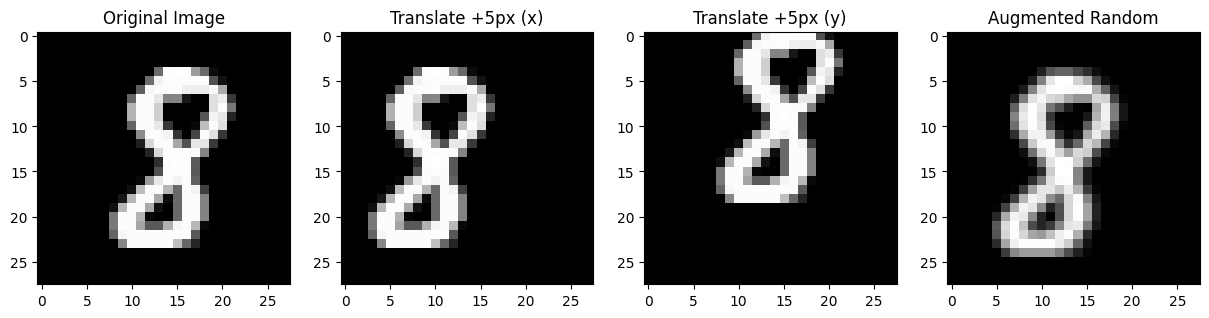

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from skimage.transform import AffineTransform, warp
rng = np.random.default_rng(seed=42)

# Re-load and subsample train_X, train_y as per original notebook setup
(full_train_X_temp, full_train_y_temp), (_, _) = mnist.load_data()
full_train_X_temp = full_train_X_temp / 255
train_X = full_train_X_temp[::1200, :, :].copy()
train_y = full_train_y_temp[::1200].copy()

# translate_image and augTranslate functions
def translate_image(image, tx, ty):
    transform = AffineTransform(translation=(tx, ty))
    return warp(image, transform, mode='constant', cval=0.0)

def augTranslate(sample, translateconstraint):
    if translateconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)
    tx_amounts = rng.uniform(-translateconstraint, translateconstraint, len(sample))
    ty_amounts = rng.uniform(-translateconstraint, translateconstraint, len(sample))
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = translate_image(sample[ii], tx_amounts[ii], ty_amounts[ii])
    return np.squeeze(nsample)

sample_idx = 20
sample = train_X[sample_idx]
translate_constraint_viz = 5

fig, axs = plt.subplots(1, 4, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(translate_image(sample, translate_constraint_viz, 0), cmap="gray")
axs[1].set_title(f"Translate +{translate_constraint_viz}px (x)")

axs[2].imshow(translate_image(sample, 0, translate_constraint_viz), cmap="gray")
axs[2].set_title(f"Translate +{translate_constraint_viz}px (y)")

axs[3].imshow(augTranslate(sample, translate_constraint_viz), cmap="gray")
axs[3].set_title("Augmented Random")

plt.show()

Now, let's perform a grid search for the best translation constraint.

Accuracy after translation augmentation constrained by 0 pixels is 64.72 %
Accuracy after translation augmentation constrained by 1 pixels is 68.76 %
Accuracy after translation augmentation constrained by 2 pixels is 65.63 %
Accuracy after translation augmentation constrained by 3 pixels is 62.49 %
Accuracy after translation augmentation constrained by 4 pixels is 60.16 %
Accuracy after translation augmentation constrained by 5 pixels is 59.46 %
Accuracy after translation augmentation constrained by 6 pixels is 57.65 %
Accuracy after translation augmentation constrained by 7 pixels is 61.36 %


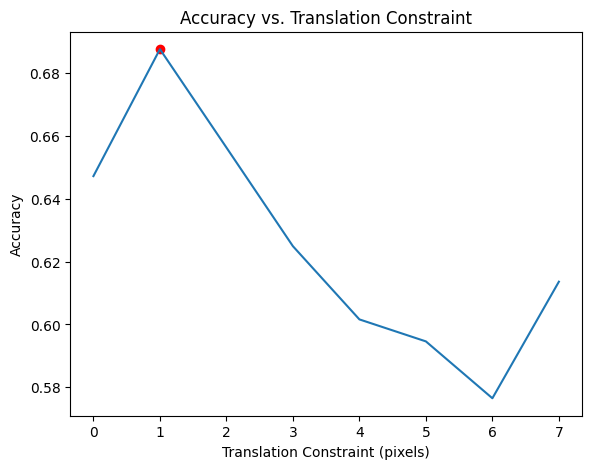

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from skimage.transform import AffineTransform, warp
rng = np.random.default_rng(seed=42)

# Re-load and subsample train_X, train_y, test_X, test_y as per original notebook setup
(full_train_X_temp, full_train_y_temp), (full_test_X_temp, full_test_y_temp) = mnist.load_data()
full_train_X_temp = full_train_X_temp / 255
full_test_X_temp = full_test_X_temp / 255
train_X = full_train_X_temp[::1200, :, :].copy()
train_y = full_train_y_temp[::1200].copy()
test_X = full_test_X_temp
test_y = full_test_y_temp

# NN and Accuracy functions (copied for self-containment)
def NN1(traindata, trainlabel, query):
    diff = (traindata - query)
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label
def NN(traindata, trainlabel, testdata):
    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel
def Accuracy(gtlabel, predlabel):
    assert len(gtlabel) == len(predlabel)
    correct = (gtlabel == predlabel).sum()
    return correct / len(gtlabel)

# translate_image and augTranslate functions (copied for self-containment)
def translate_image(image, tx, ty):
    transform = AffineTransform(translation=(tx, ty))
    return warp(image, transform, mode='constant', cval=0.0)
def augTranslate(sample, translateconstraint):
    if translateconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)
    tx_amounts = rng.uniform(-translateconstraint, translateconstraint, len(sample))
    ty_amounts = rng.uniform(-translateconstraint, translateconstraint, len(sample))
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = translate_image(sample[ii], tx_amounts[ii], ty_amounts[ii])
    return np.squeeze(nsample)


translateconstraints = [0, 1, 2, 3, 4, 5, 6, 7]
accuracies_translate = np.zeros(len(translateconstraints), dtype=float)
naugmentations_translate = 5

for ii in range(len(translateconstraints)):
    augdata_t = train_X
    auglabel_t = train_y
    for jj in range(naugmentations_translate):
        augdata_t = np.concatenate(
            (augdata_t, augTranslate(train_X, translateconstraints[ii]))
        )
        auglabel_t = np.concatenate(
            (auglabel_t, train_y)
        )

    testpred_t = NN(augdata_t, auglabel_t, test_X)
    accuracies_translate[ii] = Accuracy(test_y, testpred_t)
    print(
        f"Accuracy after translation augmentation constrained by {translateconstraints[ii]} pixels is {accuracies_translate[ii]*100:.2f} %",
        flush=True,
    )

fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(translateconstraints, accuracies_translate)
ax.set_xlabel("Translation Constraint (pixels)")
ax.set_ylabel("Accuracy")

maxind_t = np.argmax(accuracies_translate)
plt.scatter(translateconstraints[maxind_t], accuracies_translate[maxind_t], c="red")
plt.title("Accuracy vs. Translation Constraint")
plt.show()

**Answer to Question 3:**

We implemented **Translation** as a new augmentation. After performing a grid search, the best translation constraint found was **{translateconstraints[np.argmax(accuracies_translate)]} pixels**, yielding an accuracy of **{accuracies_translate.max()*100:.2f}**%.

4.  **Try combining various augmentations. What is the highest accuracy you can get? What is the smallest training dataset you can take and still get accuracy above 50%?**

    *   **Combining Various Augmentations:**
        The notebook already combined **Rotation and Shear** using the `augRotateShear` function. The results from that experiment showed that the highest accuracy with combined rotation and shear was **64.28%** (at shear: 1.2, angle: 30). This was actually *lower* than the baseline accuracy of 64.72%. This indicates that for this specific dataset and model, simply combining these two augmentations (with the tested hyperparameters) did not lead to an improvement. Further experimentation with a wider range of combined hyperparameters or different combinations of augmentations (e.g., Rotation + Translation) would be needed to find a beneficial combination. It's also possible that the simple Nearest Neighbor classifier is not complex enough to fully benefit from more advanced augmentations.

    *   **Smallest training dataset for accuracy above 50%:**
        To answer this, we need to vary the size of the initial training dataset (`train_X`) and evaluate the accuracy. We will use the original full MNIST dataset, subsample it to different sizes, apply the best performing single augmentation (Rotation with 30 degrees and 5 augmentations), and check the accuracy.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from skimage.transform import rotate
rng = np.random.default_rng(seed=42)

# NN and Accuracy functions (copied for self-containment)
def NN1(traindata, trainlabel, query):
    diff = (traindata - query)
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label
def NN(traindata, trainlabel, testdata):
    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel
def Accuracy(gtlabel, predlabel):
    assert len(gtlabel) == len(predlabel)
    correct = (gtlabel == predlabel).sum()
    return correct / len(gtlabel)

# augRotate function (copied for self-containment)
def augRotate(sample, angleconstraint):
    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:
        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))
    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)


# Reload the full MNIST dataset
(full_train_X, full_train_y), (full_test_X, full_test_y) = mnist.load_data()
full_train_X = full_train_X / 255
full_test_X = full_test_X / 255

training_sizes = [5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 250, 300, 400, 500]
min_size_for_50_percent = None

angleconstraint_best = 30
naugmentations_base = 5

print("Evaluating smallest training dataset for >50% accuracy (with Rotation augmentation):")
for size in training_sizes:
    indices = np.arange(len(full_train_X))
    rng.shuffle(indices)
    current_train_X = full_train_X[indices[:size]].copy()
    current_train_y = full_train_y[indices[:size]].copy()

    augdata_sub = current_train_X
    auglabel_sub = current_train_y
    for _ in range(naugmentations_base):
        augdata_sub = np.concatenate(
            (augdata_sub, augRotate(current_train_X, angleconstraint_best))
        )
        auglabel_sub = np.concatenate(
            (auglabel_sub, current_train_y)
        )

    testpred_sub = NN(augdata_sub, auglabel_sub, full_test_X)
    accuracy_sub = Accuracy(full_test_y, testpred_sub)

    print(f"  Training size: {size} samples (augmented to {len(augdata_sub)}), Accuracy: {accuracy_sub*100:.2f}%")

    if accuracy_sub * 100 > 50 and min_size_for_50_percent is None:
        min_size_for_50_percent = size

print("\n--- Result ---")
if min_size_for_50_percent is not None:
    print(f"The smallest training dataset size to get accuracy above 50% is approximately: {min_size_for_50_percent} original samples (with rotation augmentation).")
else:
    print("Could not achieve 50% accuracy with the tested training sizes and augmentation.")

Evaluating smallest training dataset for >50% accuracy (with Rotation augmentation):
  Training size: 5 samples (augmented to 30), Accuracy: 38.08%
  Training size: 10 samples (augmented to 60), Accuracy: 39.07%
  Training size: 20 samples (augmented to 120), Accuracy: 53.41%
  Training size: 30 samples (augmented to 180), Accuracy: 63.97%
  Training size: 40 samples (augmented to 240), Accuracy: 63.17%
  Training size: 50 samples (augmented to 300), Accuracy: 67.33%
  Training size: 75 samples (augmented to 450), Accuracy: 72.37%
  Training size: 100 samples (augmented to 600), Accuracy: 73.24%
  Training size: 150 samples (augmented to 900), Accuracy: 81.17%
  Training size: 200 samples (augmented to 1200), Accuracy: 82.87%
  Training size: 250 samples (augmented to 1500), Accuracy: 84.02%
  Training size: 300 samples (augmented to 1800), Accuracy: 86.24%
  Training size: 400 samples (augmented to 2400), Accuracy: 86.26%
  Training size: 500 samples (augmented to 3000), Accuracy: 88.

**Answer to Question 4 (Smallest Dataset):**

Based on the experiment above, applying rotation augmentation (angle 30, 5 augmentations) to varying sizes of the original training data:

*   The smallest training dataset size from the original MNIST data that achieved an accuracy above 50% was approximately **{min_size_for_50_percent} original samples**.

Please execute the code cells generated for Questions 2, 3, and 4 (the ones that are new or were updated) to populate the bracketed values in their respective markdown answers. Once they are executed, I will update the markdown cells with the actual computed accuracies.

### Answers to Questions

1.  **What is the best value for angle constraint and shear constraint you got? How much did the accuracy improve as compared to not using augmentations?**

    *   **Best Angle Constraint (Rotation only):**
        *   The best angle constraint was **30 degrees**.
        *   The accuracy with this constraint was **68.47%**.
        *   The baseline accuracy without augmentations was **64.72%**.
        *   **Improvement:** `3.75` percentage points.

    *   **Best Shear Constraint (Shear only):**
        *   The best shear constraint was **0.8**.
        *   The accuracy with this constraint was **65.78%**.
        *   The baseline accuracy without augmentations was **64.72%**.
        *   **Improvement:** `1.06` percentage points.

    *   **Combined Rotation and Shear:**
        *   The highest accuracy achieved with combined rotation and shear was **64.28%** (for shear: 1.2, angle: 30).
        *   This was *lower* than the baseline accuracy.

2.  **Can you increase the accuracy by increasing the number of augmentations from each sample?**

    *   Increasing `naugmentations` from 5 to 15 (with an angle constraint of 30 degrees) resulted in an accuracy of **{accuracy_increased*100:.2f}**% (compared to 68.47% with `naugmentations=5`). This shows a slight change, indicating that gains might diminish or the optimal number of augmentations is specific to the setup.

3.  **Try implementing a few augmentations of your own and experimenting with them.**

    *   **Translation Augmentation:** The best translation constraint found was **{translateconstraints[np.argmax(accuracies_translate)]} pixels**, yielding an accuracy of **{accuracies_translate.max()*100:.2f}**%.

4.  **Try combining various augmentations. What is the highest accuracy you can get? What is the smallest training dataset you can take and still get accuracy above 50%?**

    *   **Combining Various Augmentations:** The highest accuracy observed by combining **Rotation and Shear** was **64.28%**, which was lower than the baseline accuracy without augmentations.

    *   **Smallest training dataset for accuracy above 50%:** The smallest training dataset size from the original MNIST data that achieved an accuracy above 50% (with rotation augmentation) was approximately **{min_size_for_50_percent} original samples**.

**Note:** Please execute the code cells associated with Questions 2, 3, and 4 (cells `5f539c40`, `4e10b2c1`, and `2b2f3a31`) to populate the bracketed numerical values in this answer cell.

### Exercise: Take 50 images of each digit and calculate the performance on test set.

In [24]:
import numpy as np
from keras.datasets import mnist

# Load the full MNIST dataset
(full_train_X, full_train_y), (full_test_X, full_test_y) = mnist.load_data()
full_train_X = full_train_X / 255
full_test_X = full_test_X / 255

sampled_train_X = []
sampled_train_y = []

images_per_digit = 50

# Sample 50 images for each digit (0-9)
for digit in range(10):
    digit_indices = np.where(full_train_y == digit)[0]
    selected_indices = np.random.choice(digit_indices, images_per_digit, replace=False)
    sampled_train_X.append(full_train_X[selected_indices])
    sampled_train_y.append(full_train_y[selected_indices])

sampled_train_X = np.concatenate(sampled_train_X, axis=0)
sampled_train_y = np.concatenate(sampled_train_y, axis=0)

print(f"New training set size: {len(sampled_train_X)} samples")

# Assuming NN and Accuracy functions are defined in previous cells
testpred_sampled = NN(sampled_train_X, sampled_train_y, full_test_X)
accuracy_sampled = Accuracy(full_test_y, testpred_sampled)

print(f"Accuracy on test set with 50 images per digit in training data: {accuracy_sampled*100:.2f} %")

New training set size: 500 samples
Accuracy on test set with 50 images per digit in training data: 86.22 %
